In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


@dataclass(frozen=True)
class RodProblem:
  """Physical model of a rod under a linearly distributed load."""

  youngs_modulus: float = 200e9
  cross_section_area: float = 0.01
  load_coefficient: float = 1000.0
  length: float = 1.0

  @property
  def displacement_scale(self) -> float:
    return (
        self.load_coefficient
        * self.length**3
        / (
            self.cross_section_area
            * self.youngs_modulus
        )
    )

  def dimensionless_exact_solution(
      self,
      xi: np.ndarray,
  ) -> np.ndarray:
      return (
          -xi**3 + 3 * xi
      ) / 6

  def exact_solution(self, x: np.ndarray) -> np.ndarray:
    """Return the analytical displacement solution."""

    xi = x / self.length

    return (
        self.displacement_scale
        * self.dimensionless_exact_solution(xi)
    )

In [2]:
@dataclass(frozen=True)
class PINNConfiguration:
  """Configuration of one physics-informed neural network."""

  name: str
  hidden_layers: int
  neurons_per_layer: int
  activation: str #= "tanh"
  learning_rate: float = 1e-3
  epochs: int = 5000

  def __post_init__(self) -> None:
    if self.hidden_layers < 1:
      raise ValueError("The model must contain at least one hidden layer.")

    if self.neurons_per_layer < 1:
      raise ValueError("Each hidden layer must contain at least one neuron.")

    if self.learning_rate <= 0:
      raise ValueError("The learning rate must be positive.")

    if self.epochs < 1:
      raise ValueError("The number of epochs must be positive.")

    supported_activations = {
        "tanh", "sigmoid", "swish", "softplus"
    }

    if self.activation not in supported_activations:
      raise ValueError(
          f"Unsupported activation function: {self.activation}"
      )

In [3]:
class PINNModel:
  """One physics-informed neural-network model."""

  def __init__(
    self,
    problem: RodProblem,
    configuration: PINNConfiguration,
    number_of_collocation_points: int = 100,
    random_seed: int | None = None,
  ) -> None:
    if number_of_collocation_points < 2:
      raise ValueError("At least two collocation points are required.")

    self.problem = problem
    self.configuration = configuration
    self.number_of_collocation_points = (number_of_collocation_points)

    if random_seed is not None:
      np.random.seed(random_seed)
      tf.random.set_seed(random_seed)

    self.x_collocation = tf.convert_to_tensor(
      np.linspace(
        0.0,
        1.0,
        #self.problem.length,
        self.number_of_collocation_points,
      ).reshape(-1, 1),
      dtype=tf.float32,
    )

    self.model = self._build_network()

    self.optimizer = tf.keras.optimizers.Adam(
    learning_rate=self.configuration.learning_rate
    )

    self.loss_history: list[float] = []

  def _build_network(self) -> tf.keras.Model:
    """Construct the neural-network architecture."""

    layers: list[tf.keras.layers.Layer] = [
      tf.keras.layers.Input(shape=(1,))
    ]

    for _ in range(self.configuration.hidden_layers):
      layers.append(
        tf.keras.layers.Dense(
          self.configuration.neurons_per_layer,
          activation=self.configuration.activation,
        )
      )

    layers.append(
      tf.keras.layers.Dense(
        1,
        activation=None,
      )
    )

    return tf.keras.Sequential(
      layers,
      name=self.configuration.name,
    )

  def compute_loss_components(self,) -> tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
    """Calculate PDE and boundary-condition losses."""

    x = self.x_collocation

    with tf.GradientTape() as second_tape:
      second_tape.watch(x)

      with tf.GradientTape() as first_tape:
        first_tape.watch(x)
        displacement = self.model(
          x,
          training=True,
        )

      first_derivative = first_tape.gradient(
        displacement,
        x,
      )

      if first_derivative is None:
        raise RuntimeError(
            "TensorFlow could not calculate du/dx."
        )

    second_derivative = second_tape.gradient(
      first_derivative,
      x,
    )

    if second_derivative is None:
      raise RuntimeError("TensorFlow could not calculate d²u/dx².")

    pde_residual = second_derivative + x

    pde_loss = tf.reduce_mean(
      tf.square(pde_residual)
    )

    x_zero = tf.constant(
      [[0.0]],
      dtype=tf.float32,
    )

    displacement_at_zero = self.model(
      x_zero,
      training=True,
    )

    displacement_boundary_loss = tf.reduce_mean(
      tf.square(displacement_at_zero)
    )

    x_length = tf.constant(
      [[1.0]],
      dtype=tf.float32,
    )

    with tf.GradientTape() as boundary_tape:
      boundary_tape.watch(x_length)

      displacement_at_length = self.model(
        x_length,
        training=True,
      )

    derivative_at_length = boundary_tape.gradient(
      displacement_at_length,
      x_length,
    )

    if derivative_at_length is None:
      raise RuntimeError("TensorFlow could not calculate du/dx at x=L.")

    derivative_boundary_loss = tf.reduce_mean(
      tf.square(derivative_at_length)
    )

    return (
      pde_loss,
      displacement_boundary_loss,
      derivative_boundary_loss,
    )

  def compute_total_loss(self) -> tf.Tensor:
    """Return the complete PINN loss."""

    pde_loss, boundary_loss_1, boundary_loss_2 = (
      self.compute_loss_components()
    )

    return (
      pde_loss
      + boundary_loss_1
      + boundary_loss_2
    )

  @tf.function
  def _train_step(self) -> tf.Tensor:
    """Perform one optimizer step."""

    with tf.GradientTape() as tape:
      loss = self.compute_total_loss()

    gradients = tape.gradient(
      loss,
      self.model.trainable_variables,
    )

    gradient_variable_pairs = [
      (gradient, variable)
      for gradient, variable in zip(
        gradients,
        self.model.trainable_variables,
      )
      if gradient is not None
    ]

    self.optimizer.apply_gradients(
      gradient_variable_pairs
    )

    return loss

  def train(
    self,
    print_interval: int = 500,
  ) -> None:
    """Train the model and save its loss history."""

    self.loss_history.clear()

    for epoch in range(
      1,
      self.configuration.epochs + 1,
    ):
      loss = self._train_step()
      loss_value = float(loss.numpy())

      self.loss_history.append(loss_value)

      if (
        print_interval > 0
        and (
          epoch == 1
          or epoch % print_interval == 0
          or epoch == self.configuration.epochs
        )
      ):
        print(
          f"{self.configuration.name}: "
          f"epoch {epoch}/"
          f"{self.configuration.epochs}, "
          f"loss = {loss_value:.6e}"
        )

  def predict(
    self,
    xi: np.ndarray,
  ) -> np.ndarray:
    """Predict dimensionless displacement values."""

    xi_tensor = tf.convert_to_tensor(
      xi,
      dtype=tf.float32,
    )

    predictions = self.model(
      xi_tensor,
      training=False,
    )

    return predictions.numpy()

  def predict_physical(
      self,
      x: np.ndarray,
  ) -> np.ndarray:

    """Predict physical displacement in metres."""

    xi = x / self.problem.length

    dimensionless_prediction = self.predict(xi)

    return (
        self.problem.displacement_scale
        * dimensionless_prediction
    )

  def absolute_error(
    self,
    x: np.ndarray,
  ) -> np.ndarray:
    """Return absolute error against the exact solution."""

    prediction = self.predict_physical(x)
    exact = self.problem.exact_solution(x)

    return np.abs(exact - prediction)

  def mean_absolute_error(
    self,
    x: np.ndarray,
  ) -> float:
    """Return mean absolute error."""

    return float(
      np.mean(self.absolute_error(x))
    )

  def maximum_absolute_error(
    self,
    x: np.ndarray,
  ) -> float:
    """Return maximum absolute error."""

    return float(
      np.max(self.absolute_error(x))
    )

  @property
  def number_of_parameters(self) -> int:
    """Return the number of trainable model parameters."""

    return int(
      self.model.count_params()
    )

In [4]:
class ModelComparison:
  """Train, evaluate and compare multiple PINN models."""

  def __init__(
    self,
    problem: RodProblem,
    models: Sequence[PINNModel],
    number_of_test_points: int = 300,
  ) -> None:
    if not models:
      raise ValueError("At least one model is required.")

    self.problem = problem
    self.models = list(models)

    self.x_test = np.linspace(
      0,
      self.problem.length,
      number_of_test_points,
    ).reshape(-1, 1)

  def train_all(self) -> None:
    """Train every configured model."""

    for index, model in enumerate(
      self.models,
      start=1,
    ):
      print()
      print(
        f"Training model {index}/"
        f"{len(self.models)}: "
        f"{model.configuration.name}"
      )

      model.train()

  def print_summary(self) -> None:
    """Print a clean comparison table."""

    headings = (
      "Model",
      "Layers",
      "Neurons",
      "Parameters",
      "Final loss",
      "Mean error",
      "Max error",
    )

    rows = []

    for model in self.models:
      final_loss = (
        model.loss_history[-1]
        if model.loss_history
        else float("nan")
      )

      rows.append(
        (
          model.configuration.name,
          model.configuration.hidden_layers,
          model.configuration.neurons_per_layer,
          model.number_of_parameters,
          final_loss,
          model.mean_absolute_error(self.x_test),
          model.maximum_absolute_error(self.x_test),
        )
      )

    header_format = (
      "{:<18} {:>8} {:>9} {:>12} "
      "{:>14} {:>14} {:>14}"
    )

    print()
    print(header_format.format(*headings))
    print("-" * 98)

    for row in rows:
      print(
        header_format.format(
          row[0],
          row[1],
          row[2],
          row[3],
          f"{row[4]:.4e}",
          f"{row[5]:.4e}",
          f"{row[6]:.4e}",
        )
      )

  def plot_solutions(self) -> None:
    """Compare predicted and exact displacement curves."""

    exact_solution = self.problem.exact_solution(
      self.x_test
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
      self.x_test,
      exact_solution,
      linewidth=3,
      label="Exact solution",
    )

    for model in self.models:
      prediction = model.predict_physical(
        self.x_test
      )

      plt.plot(
        self.x_test,
        prediction,
        label=model.configuration.name,
      )

    plt.xlabel("x (m)")
    plt.ylabel("Displacement u(x)")
    plt.title(
      "PINN predictions compared with exact solution"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

  def plot_absolute_errors(self) -> None:
    """Plot the absolute error of every model."""

    plt.figure(figsize=(9, 6))

    for model in self.models:
      errors = model.absolute_error(
        self.x_test
      )

      plt.plot(
        self.x_test,
        errors,
        label=model.configuration.name,
      )

    plt.xlabel("x (m)")
    plt.ylabel("Absolute error")
    plt.title(
      "Absolute-error comparison"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

  def plot_loss_histories(self) -> None:
    """Compare model training-loss histories."""

    plt.figure(figsize=(9, 6))

    for model in self.models:
      plt.semilogy(
        range(
          1,
          len(model.loss_history) + 1,
        ),
        model.loss_history,
        label=model.configuration.name,
      )

    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("Training-loss comparison")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

  def plot_error_summary(self) -> None:
    """Display mean and maximum error by model."""

    model_names = [
      model.configuration.name
      for model in self.models
    ]

    mean_errors = [
      model.mean_absolute_error(self.x_test)
      for model in self.models
    ]

    maximum_errors = [
      model.maximum_absolute_error(self.x_test)
      for model in self.models
    ]

    positions = np.arange(
      len(self.models)
    )

    width = 0.35

    plt.figure(figsize=(10, 6))

    plt.bar(
      positions - width / 2,
      mean_errors,
      width=width,
      label="Mean absolute error",
    )

    plt.bar(
      positions + width / 2,
      maximum_errors,
      width=width,
      label="Maximum absolute error",
    )

    plt.xticks(
      positions,
      model_names,
      rotation=20,
    )

    plt.ylabel("Error")
    plt.title("Model-error summary")
    plt.grid(
      axis="y",
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

  def show_all_results(self) -> None:
    """Print and visualize all comparison results."""

    self.print_summary()
    self.plot_solutions()
    self.plot_absolute_errors()
    self.plot_loss_histories()
    self.plot_error_summary()




In [5]:
def read_positive_integer(
  prompt: str,
) -> int:
  """Read a positive integer from the user."""

  while True:
    try:
      value = int(input(prompt))

      if value < 1:
        raise ValueError

      return value

    except ValueError:
      print(
        "Please enter a positive whole number."
      )


def read_positive_float(
  prompt: str,
) -> float:
  """Read a positive floating-point number."""

  while True:
    try:
      value = float(input(prompt))

      if value <= 0:
        raise ValueError

      return value

    except ValueError:
      print(
        "Please enter a positive number."
      )

def read_activation_function() -> str:
  """Ask for an activation suitable for a second-order PINN."""

  supported_activations = {
    "tanh",
    "sigmoid",
    "swish",
    "softplus",
  }

  while True:
    activation = input(
      "Activation function "
      "(tanh, sigmoid, swish, softplus): "
    ).strip().lower()

    if not activation:
      return "tanh"

    if activation in supported_activations:
      return activation

    print(
      "Please choose tanh, sigmoid, swish, or softplus."
    )

def read_model_configurations(
) -> list[PINNConfiguration]:
  """Ask the user which network architectures to compare."""

  number_of_models = read_positive_integer(
    "How many models do you want to compare? "
  )

  configurations = []

  for index in range(
    1,
    number_of_models + 1,
  ):
    print()
    print(f"Configuration for model {index}")

    default_name = f"Model {index}"

    name = input(
      f"Model name [{default_name}]: "
    ).strip()

    if not name:
      name = default_name

    #Make name TensorFlow safe
    name = name.replace(" ", "_")

    if not name[0].isalpha():
      name = f"model_{name}"

    hidden_layers = read_positive_integer(
      "Number of hidden layers: "
    )

    neurons_per_layer = read_positive_integer(
      "Neurons per hidden layer: "
    )

    activation = read_activation_function()

    if not activation:
      activation = "tanh"

    learning_rate = read_positive_float(
      "Learning rate, for example 0.001: "
    )

    epochs = read_positive_integer(
      "Number of epochs: "
    )

    configurations.append(
      PINNConfiguration(
        name=name,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer,
        activation=activation,
        learning_rate=learning_rate,
        epochs=epochs,
      )
    )

  return configurations

In [6]:
def main() -> None:
  """Create, train and compare user-configured PINNs."""

  problem = RodProblem()
  configurations = read_model_configurations()

  models = [
    PINNModel(
      problem=problem,
      configuration=configuration,
      number_of_collocation_points=100,
      random_seed=42 + index,
    )
    for index, configuration in enumerate(
      configurations
    )
  ]

  comparison = ModelComparison(
    problem=problem,
    models=models,
  )

  comparison.train_all()
  comparison.show_all_results()


  if __name__ == "__main__":
    main()

How many models do you want to compare? 2

Configuration for model 1
Model name [Model 1]: Small_PINN
Number of hidden layers: 2
Neurons per hidden layer: 20
Activation function (tanh, sigmoid, swish, softplus): swish
Learning rate, for example 0.001: 0.001
Number of epochs: 5000

Configuration for model 2
Model name [Model 2]: Deep_PINN
Number of hidden layers: 4
Neurons per hidden layer: 40
Activation function (tanh, sigmoid, swish, softplus): swish
Learning rate, for example 0.001: 0.001
Number of epochs: 5000

Training model 1/2: Small_PINN
Small_PINN: epoch 1/5000, loss = 3.155352e-01
Small_PINN: epoch 500/5000, loss = 5.537164e-05
Small_PINN: epoch 1000/5000, loss = 4.458482e-05
Small_PINN: epoch 1500/5000, loss = 4.061040e-05
Small_PINN: epoch 2000/5000, loss = 3.739454e-05
Small_PINN: epoch 2500/5000, loss = 3.374706e-05
Small_PINN: epoch 3000/5000, loss = 2.969585e-05
Small_PINN: epoch 3500/5000, loss = 2.586942e-05
Small_PINN: epoch 4000/5000, loss = 2.141023e-05
Small_PINN: 

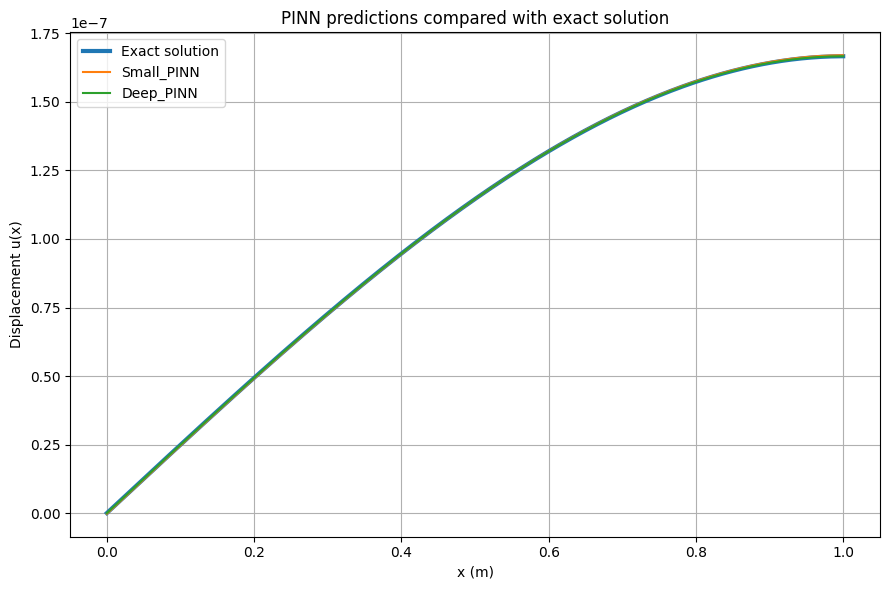

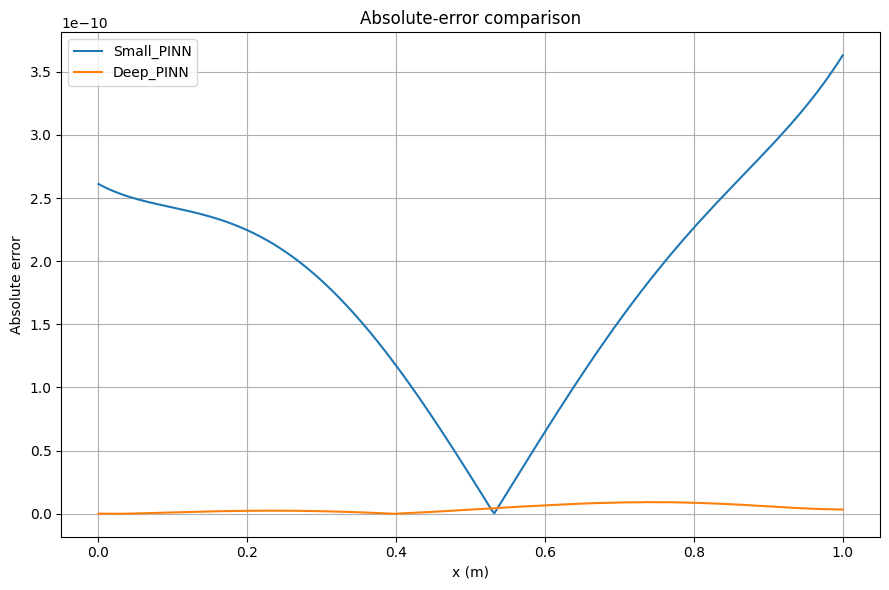

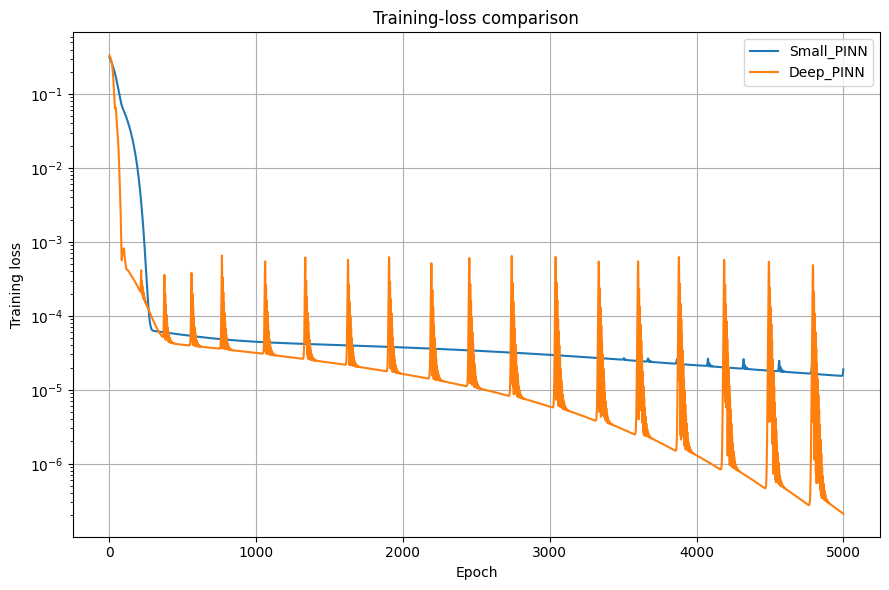

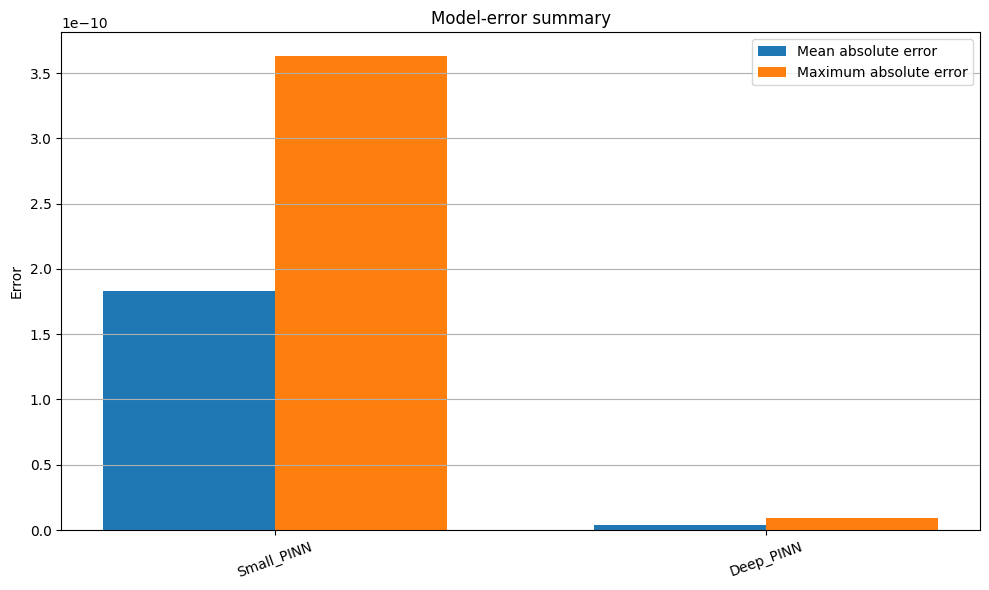

In [ ]:
main()